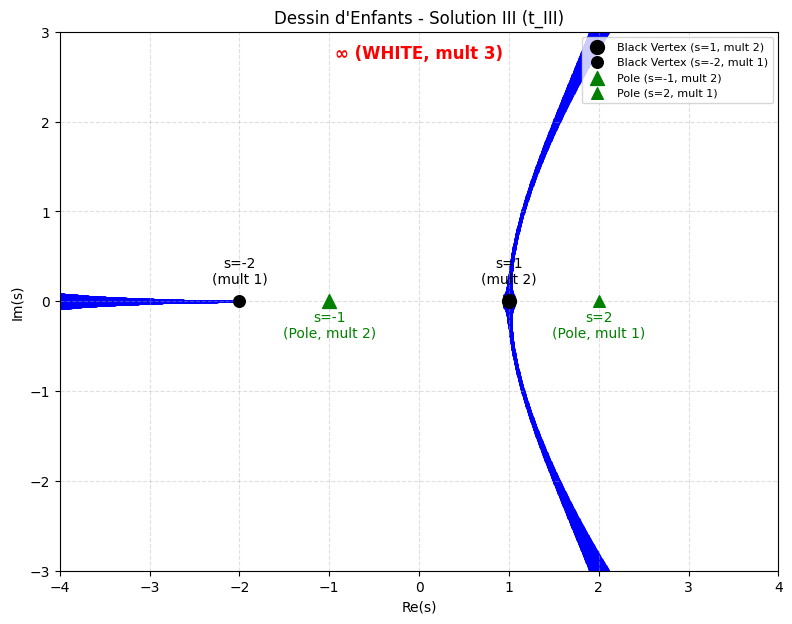

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Область просмотра
# Охватывает все вещественные критические точки: s = -2, -1, 1, 2
# Комплексных критических точек нет (все корни вещественные или бесконечность)
X_min = -4.0
X_max = 4.0
Y_min = -3.0
Y_max = 3.0

resolution = 2000   # Высокое разрешение для четких линий
epsilon = 0.005     # Допуск для попадания на отрезок [0, 1]

# 2. Создаем сетку в комплексной плоскости
x = np.linspace(X_min, X_max, resolution)
y = np.linspace(Y_min, Y_max, resolution)
S_real, S_imag = np.meshgrid(x, y)
s = S_real + 1j * S_imag

# 3. Функция Беля для t_III
# t = (s-1)^2 * (s+2) / ((s+1)^2 * (s-2))
numerator = (s - 1)**2 * (s + 2)
denominator = (s + 1)**2 * (s - 2)

# 4. Маска безопасности: исключаем полюса s=-1 и s=2
# (из фото: t(s) -> infinity при s->-1 и s->2)
safe_mask = np.abs(denominator) > 1e-5

# Вычисляем t(s)
t_val = np.zeros_like(s, dtype=complex)
t_val[safe_mask] = numerator[safe_mask] / denominator[safe_mask]

# 5. Фильтр: прообраз отрезка [0, 1]
# Условие: |Im(t)| <= epsilon, 0 <= Re(t) <= 1, и точка не в полюсе
condition = (np.abs(t_val.imag) <= epsilon) & \
            (t_val.real >= 0) & (t_val.real <= 1) & \
            safe_mask

a_III = S_real[condition]
b_III = S_imag[condition]

# 6. Построение графика
plt.figure(figsize=(10, 7))
plt.scatter(a_III, b_III, s=0.5, c='blue', alpha=0.8)  # Синий цвет

# Добавляем маркеры для вершин согласно паспорту [3 | 1,2 | 1,2]

# Белая вершина (t=1) на бесконечности
# На плоскости это "концы" графа, но для схемы обозначим точку "вдали"
plt.text(0, Y_max - 0.3, '∞ (WHITE, mult 3)', fontsize=12, color='red', ha='center', fontweight='bold')

# Черные вершины (t=0)
plt.scatter([1], [0], c='black', s=100, zorder=5, label='Black Vertex (s=1, mult 2)')
plt.text(1, 0.2, 's=1\n(mult 2)', fontsize=10, color='black', ha='center')

plt.scatter([-2], [0], c='black', s=70, zorder=5, label='Black Vertex (s=-2, mult 1)')
plt.text(-2, 0.2, 's=-2\n(mult 1)', fontsize=10, color='black', ha='center')

# Полюса (t=∞)
plt.scatter([-1], [0], c='green', marker='^', s=100, zorder=5, label='Pole (s=-1, mult 2)')
plt.text(-1, -0.4, 's=-1\n(Pole, mult 2)', fontsize=10, color='green', ha='center')

plt.scatter([2], [0], c='green', marker='^', s=70, zorder=5, label='Pole (s=2, mult 1)')
plt.text(2, -0.4, 's=2\n(Pole, mult 1)', fontsize=10, color='green', ha='center')

plt.xlim(X_min, X_max)
plt.ylim(Y_min, Y_max)
plt.xlabel('Re(s)')
plt.ylabel('Im(s)')
plt.title("Dessin d'Enfants - Solution III (t_III)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(loc='upper right', fontsize=8)
plt.show()

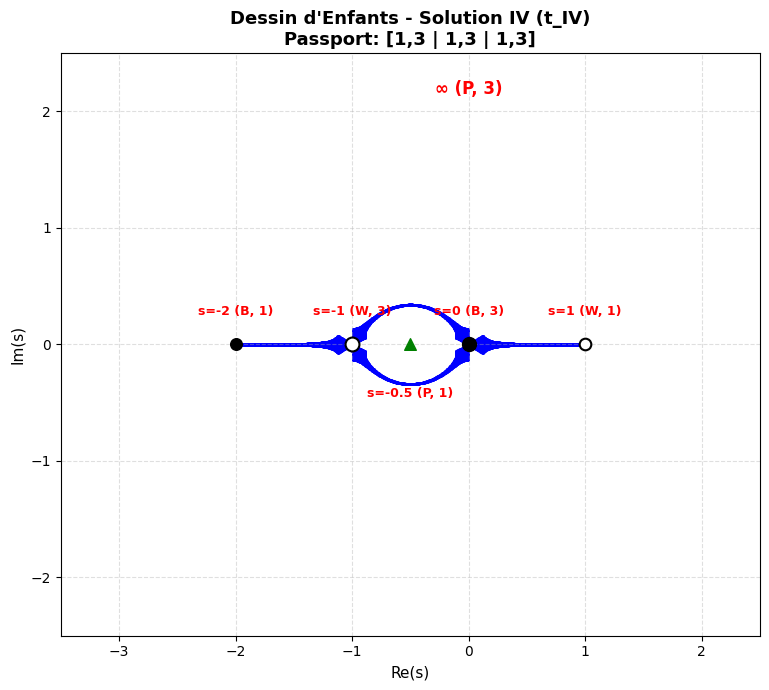

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Область просмотра
# Охватывает все вещественные критические точки: s = -2, -1, -0.5, 0, 1
X_min, X_max = -3.5, 2.5
Y_min, Y_max = -2.5, 2.5

resolution = 2500   # Высокое разрешение для чётких линий
epsilon = 0.005     # Допуск для попадания на отрезок [0, 1]

# 2. Создаём равномерную сетку в комплексной плоскости
x = np.linspace(X_min, X_max, resolution)
y = np.linspace(Y_min, Y_max, resolution)
S_real, S_imag = np.meshgrid(x, y)
s = S_real + 1j * S_imag

# 3. Функция Беля для t_IV
# t = s^3 * (s + 2) / (2s + 1)
numerator = s**3 * (s + 2)
denominator = 2*s + 1

# 4. Маска безопасности: исключаем полюс s = -0.5
safe_mask = np.abs(denominator) > 1e-5

# Вычисляем t(s) только для безопасных точек
t_val = np.zeros_like(s, dtype=complex)
t_val[safe_mask] = numerator[safe_mask] / denominator[safe_mask]

# 5. Фильтр: прообраз отрезка [0, 1]
condition = (np.abs(t_val.imag) <= epsilon) & \
            (t_val.real >= 0) & (t_val.real <= 1) & \
            safe_mask

a_IV = S_real[condition]
b_IV = S_imag[condition]

# 6. Построение графика
plt.figure(figsize=(10, 7))
plt.scatter(a_IV, b_IV, s=0.5, c='blue', alpha=0.85)  #  График синий

# === Отмечаем вершины и полюса ===

# Чёрные вершины (t=0): s=0 (кратность 3), s=-2 (кратность 1)
plt.scatter([0], [0], c='black', s=100, zorder=5)
plt.text(0, 0.25, 's=0 (B, 3)', fontsize=9, color='red', ha='center', fontweight='bold')

plt.scatter([-2], [0], c='black', s=70, zorder=5)
plt.text(-2, 0.25, 's=-2 (B, 1)', fontsize=9, color='red', ha='center', fontweight='bold')

# Белые вершины (t=1): s=1 (кратность 1), s=-1 (кратность 3)
plt.scatter([1], [0], c='white', s=70, edgecolors='black', linewidths=1.5, zorder=5)
plt.text(1, 0.25, 's=1 (W, 1)', fontsize=9, color='red', ha='center', fontweight='bold')

plt.scatter([-1], [0], c='white', s=100, edgecolors='black', linewidths=1.5, zorder=5)
plt.text(-1, 0.25, 's=-1 (W, 3)', fontsize=9, color='red', ha='center', fontweight='bold')

# Полюса (t=∞): s=-0.5 (кратность 1), s=∞ (кратность 3)
plt.scatter([-0.5], [0], c='green', marker='^', s=70, zorder=5)
plt.text(-0.5, -0.45, 's=-0.5 (P, 1)', fontsize=9, color='red', ha='center', fontweight='bold')

# Вершина в бесконечности (валентность 3)
plt.text(0, Y_max - 0.35, '∞ (P, 3)', fontsize=12, color='red', ha='center', fontweight='bold')

# Настройки оформления
plt.xlim(X_min, X_max)
plt.ylim(Y_min, Y_max)
plt.xlabel('Re(s)', fontsize=11)
plt.ylabel('Im(s)', fontsize=11)
plt.title("Dessin d'Enfants - Solution IV (t_IV)\nPassport: [1,3 | 1,3 | 1,3]", fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

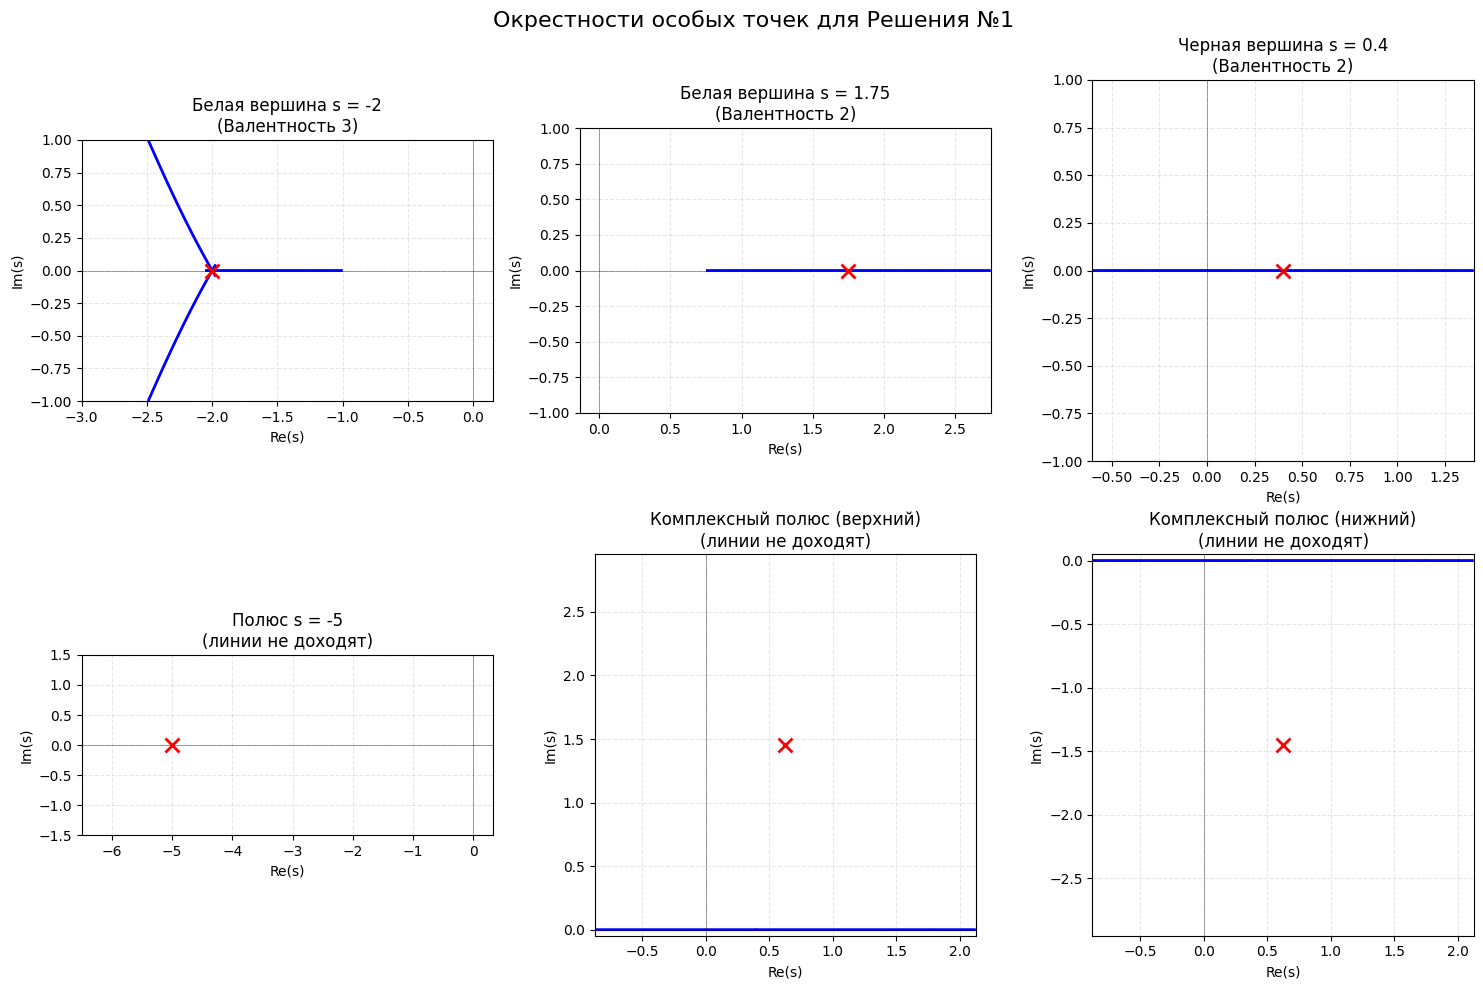

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def belyi_t1(s):
    """Функция Белого для Решения №1"""
    num = 27 * (5*s - 2)**2
    den = (s + 5) * (4*s**2 - 5*s + 10)**2
    return num / den

# Вычисляем комплексные полюса заранее
im_pole = 3 * np.sqrt(15) / 8  # примерно 1.452

# --- НАСТРОЙКИ ТОЧЕК И МАСШТАБОВ ---
# Формат: {"center": координата точки, "window": радиус обзора, "title": Название}
# Меняйте параметр 'window', чтобы приближать или отдалять!
points_of_interest = [
    {"center": -2.0, "window": 1.0, "title": "Белая вершина s = -2\n(Валентность 3)"},
    {"center": 1.75, "window": 1.0, "title": "Белая вершина s = 1.75\n(Валентность 2)"},
    {"center": 0.4,  "window": 1.0, "title": "Черная вершина s = 0.4\n(Валентность 2)"},
    {"center": -5.0, "window": 1.5, "title": "Полюс s = -5\n(линии не доходят)"},
    {"center": 0.625 + 1j * im_pole, "window": 1.5, "title": "Комплексный полюс (верхний)\n(линии не доходят)"},
    {"center": 0.625 - 1j * im_pole, "window": 1.5, "title": "Комплексный полюс (нижний)\n(линии не доходят)"}
]

resolution = 1000 # Разрешение сетки для каждого окошка

# Создаем сетку из 6 графиков (2 строки, 3 колонки)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Окрестности особых точек для Решения №1", fontsize=16)

# Идем по нашему списку точек и рисуем каждую в своем окошке
for ax, point_data in zip(axes.flatten(), points_of_interest):

    center_val = point_data["center"]
    win = point_data["window"]

    # Автоматически вычисляем x_min, x_max, y_min, y_max на основе центра и окошка
    x_min = np.real(center_val) - win
    x_max = np.real(center_val) + win
    y_min = np.imag(center_val) - win
    y_max = np.imag(center_val) + win

    # Создаем сетку для конкретного окошка
    x = np.linspace(x_min, x_max, resolution)
    y = np.linspace(y_min, y_max, resolution)
    X, Y = np.meshgrid(x, y)
    S = X + 1j * Y

    # Вычисляем функцию
    with np.errstate(divide='ignore', invalid='ignore'):
        T = belyi_t1(S)
        T_re = np.real(T)
        T_im = np.imag(T)

    # Маскируем (оставляем только t от 0 до 1)
    mask = (T_re >= -1e-5) & (T_re <= 1.00001)
    T_im_masked = np.where(mask, T_im, np.nan)

    # Рисуем линии
    ax.contour(X, Y, T_im_masked, levels=[0], colors='blue', linewidths=2)

    # Отмечаем саму особую точку красным крестиком для наглядности!
    ax.plot(np.real(center_val), np.imag(center_val), marker='x', color='red', markersize=10, mew=2)

    # Оформление графика
    ax.set_title(point_data["title"], fontsize=12)
    ax.set_xlabel("Re(s)", fontsize=10)
    ax.set_ylabel("Im(s)", fontsize=10)
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.5, alpha=0.5)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_aspect('equal') # Квадратные пропорции

plt.tight_layout()
plt.show()


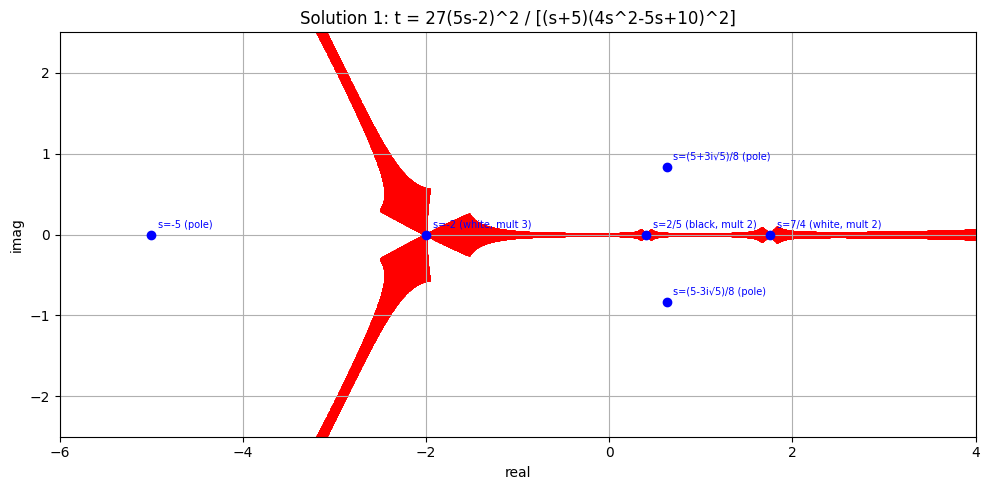

In [ ]:
#решение 1
import matplotlib.pyplot as plt
import numpy as np

# Параметры окна — надо охватить все критические точки:
# s = -5, -2, 2/5, 7/4, и комплексные полюса с Im ~ ±0.75*sqrt(5) ~ ±1.68
X_min = -6.0
X_max = 4.0
Y_min = -2.5
Y_max = 2.5
resolution = 3000
epsilon = 0.01

def beta(z):
    num = 27 * (5*z - 2)**2
    den = (z + 5) * (4*z**2 - 5*z + 10)**2
    return num / den

a1 = np.array([])
b1 = np.array([])

for x in range(resolution):
    for y in range(resolution):
        z = complex(
            X_min + x*(X_max - X_min)/resolution,
            Y_min + y*(Y_max - Y_min)/resolution
        )
        try:
            B = beta(z)
            if -epsilon <= B.imag <= epsilon and 0 <= B.real <= 1:
                a1 = np.append(a1, z.real)
                b1 = np.append(b1, z.imag)
        except:
            pass

fig, axs = plt.subplots(figsize=(10, 5))
axs.axis((X_min, X_max, Y_min, Y_max))
axs.set_xlabel('real')
axs.set_ylabel('imag')
axs.set_title("Solution 1: t = 27(5s-2)^2 / [(s+5)(4s^2-5s+10)^2]")
axs.grid(True)
axs.scatter(a1, b1, s=1, c="r")

# Отмечаем критические точки
critical_points = {
    's=-2 (white, mult 3)': (-2, 0),
    's=7/4 (white, mult 2)': (7/4, 0),
    's=2/5 (black, mult 2)': (2/5, 0),
    's=-5 (pole)': (-5, 0),
    's=(5+3i√5)/8 (pole)': (5/8, 3*np.sqrt(5)/8),
    's=(5-3i√5)/8 (pole)': (5/8, -3*np.sqrt(5)/8),
}
for label, (cx, cy) in critical_points.items():
    axs.plot(cx, cy, 'bo', markersize=6)
    axs.annotate(label, (cx, cy), textcoords="offset points",
                 xytext=(5, 5), fontsize=7, color='blue')

plt.tight_layout()
plt.show()


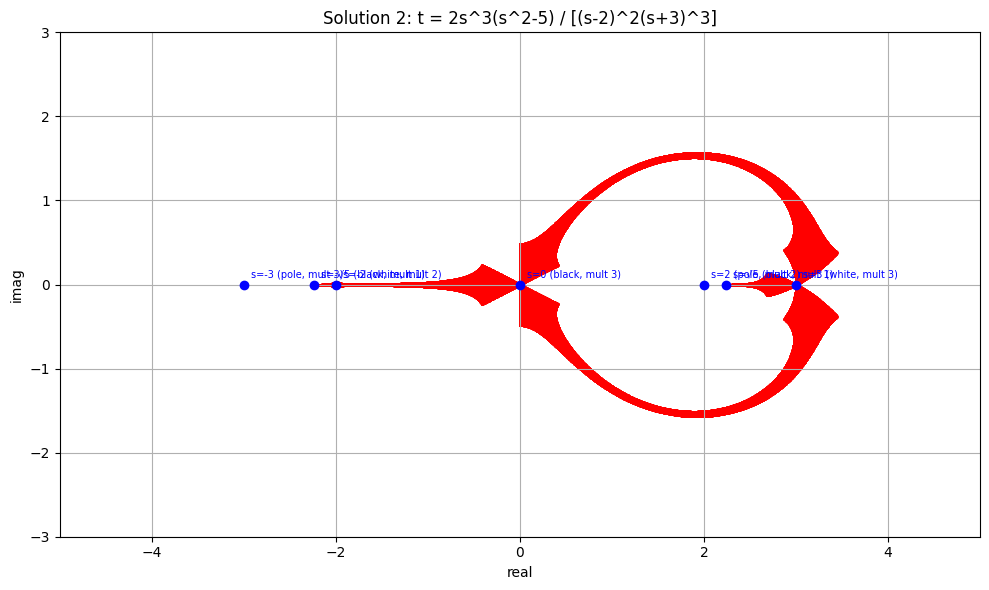

In [ ]:
#решение 2
import matplotlib.pyplot as plt
import numpy as np

X_min = -5.0
X_max = 5.0
Y_min = -3.0
Y_max = 3.0
resolution = 3000
epsilon = 0.01

def beta(z):
    num = 2 * z**3 * (z**2 - 5)
    den = (z - 2)**2 * (z + 3)**3
    return num / den

a1 = np.array([])
b1 = np.array([])

for x in range(resolution):
    for y in range(resolution):
        z = complex(
            X_min + x*(X_max - X_min)/resolution,
            Y_min + y*(Y_max - Y_min)/resolution
        )
        try:
            B = beta(z)
            # избегаем полюсов
            if abs(z - 2) > 0.05 and abs(z + 3) > 0.05:
                if -epsilon <= B.imag <= epsilon and 0 <= B.real <= 1:
                    a1 = np.append(a1, z.real)
                    b1 = np.append(b1, z.imag)
        except:
            pass

fig, axs = plt.subplots(figsize=(10, 6))
axs.axis((X_min, X_max, Y_min, Y_max))
axs.set_xlabel('real')
axs.set_ylabel('imag')
axs.set_title("Solution 2: t = 2s^3(s^2-5) / [(s-2)^2(s+3)^3]")
axs.grid(True)
axs.scatter(a1, b1, s=1, c="r")

critical_points = {
    's=-2 (white, mult 2)': (-2, 0),
    's=3 (white, mult 3)': (3, 0),
    's=0 (black, mult 3)': (0, 0),
    's=√5 (black, mult 1)': (np.sqrt(5), 0),
    's=-√5 (black, mult 1)': (-np.sqrt(5), 0),
    's=2 (pole, mult 2)': (2, 0),
    's=-3 (pole, mult 3)': (-3, 0),
}
for label, (cx, cy) in critical_points.items():
    axs.plot(cx, cy, 'bo', markersize=6)
    axs.annotate(label, (cx, cy), textcoords="offset points",
                 xytext=(5, 5), fontsize=7, color='blue')

plt.tight_layout()
plt.show()


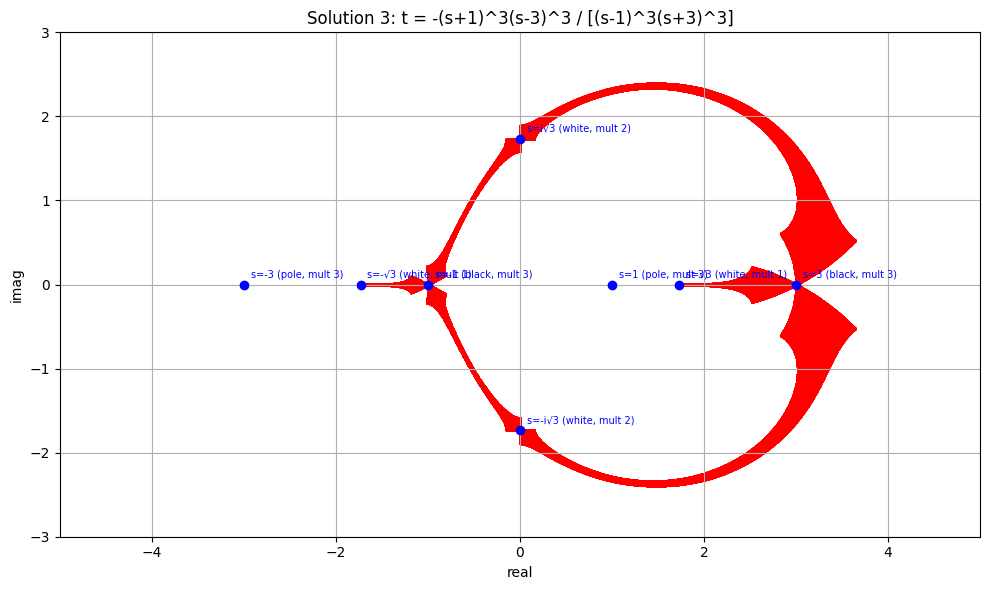

In [ ]:
#решение 3
import matplotlib.pyplot as plt
import numpy as np

X_min = -5.0
X_max = 5.0
Y_min = -3.0
Y_max = 3.0
resolution = 3000
epsilon = 0.01

def beta(z):
    num = -((z + 1)**3) * ((z - 3)**3)
    den = ((z - 1)**3) * ((z + 3)**3)
    return num / den

a1 = np.array([])
b1 = np.array([])

for x in range(resolution):
    for y in range(resolution):
        z = complex(
            X_min + x*(X_max - X_min)/resolution,
            Y_min + y*(Y_max - Y_min)/resolution
        )
        try:
            B = beta(z)
            if abs(z - 1) > 0.05 and abs(z + 3) > 0.05:
                if -epsilon <= B.imag <= epsilon and 0 <= B.real <= 1:
                    a1 = np.append(a1, z.real)
                    b1 = np.append(b1, z.imag)
        except:
            pass

fig, axs = plt.subplots(figsize=(10, 6))
axs.axis((X_min, X_max, Y_min, Y_max))
axs.set_xlabel('real')
axs.set_ylabel('imag')
axs.set_title("Solution 3: t = -(s+1)^3(s-3)^3 / [(s-1)^3(s+3)^3]")
axs.grid(True)
axs.scatter(a1, b1, s=1, c="r")

critical_points = {
    's=i√3 (white, mult 2)': (0, np.sqrt(3)),
    's=-i√3 (white, mult 2)': (0, -np.sqrt(3)),
    's=√3 (white, mult 1)': (np.sqrt(3), 0),
    's=-√3 (white, mult 1)': (-np.sqrt(3), 0),
    's=-1 (black, mult 3)': (-1, 0),
    's=3 (black, mult 3)': (3, 0),
    's=1 (pole, mult 3)': (1, 0),
    's=-3 (pole, mult 3)': (-3, 0),
}
for label, (cx, cy) in critical_points.items():
    axs.plot(cx, cy, 'bo', markersize=6)
    axs.annotate(label, (cx, cy), textcoords="offset points",
                 xytext=(5, 5), fontsize=7, color='blue')

plt.tight_layout()
plt.show()


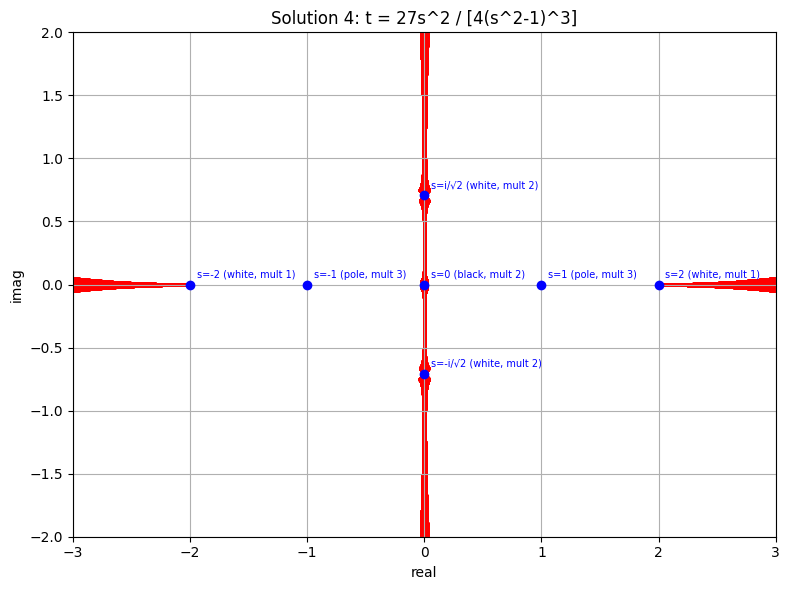

In [ ]:
#решение 4
import matplotlib.pyplot as plt
import numpy as np

X_min = -3.0
X_max = 3.0
Y_min = -2.0
Y_max = 2.0
resolution = 3000
epsilon = 0.01

def beta(z):
    num = 27 * z**2
    den = 4 * (z**2 - 1)**3
    return num / den

a1 = np.array([])
b1 = np.array([])

for x in range(resolution):
    for y in range(resolution):
        z = complex(
            X_min + x*(X_max - X_min)/resolution,
            Y_min + y*(Y_max - Y_min)/resolution
        )
        try:
            B = beta(z)
            if abs(z - 1) > 0.05 and abs(z + 1) > 0.05:
                if -epsilon <= B.imag <= epsilon and 0 <= B.real <= 1:
                    a1 = np.append(a1, z.real)
                    b1 = np.append(b1, z.imag)
        except:
            pass

fig, axs = plt.subplots(figsize=(8, 6))
axs.axis((X_min, X_max, Y_min, Y_max))
axs.set_xlabel('real')
axs.set_ylabel('imag')
axs.set_title("Solution 4: t = 27s^2 / [4(s^2-1)^3]")
axs.grid(True)
axs.scatter(a1, b1, s=1, c="r")

critical_points = {
    's=0 (black, mult 2)': (0, 0),
    's=2 (white, mult 1)': (2, 0),
    's=-2 (white, mult 1)': (-2, 0),
    's=i/√2 (white, mult 2)': (0, 1/np.sqrt(2)),
    's=-i/√2 (white, mult 2)': (0, -1/np.sqrt(2)),
    's=1 (pole, mult 3)': (1, 0),
    's=-1 (pole, mult 3)': (-1, 0),
}
for label, (cx, cy) in critical_points.items():
    axs.plot(cx, cy, 'bo', markersize=6)
    axs.annotate(label, (cx, cy), textcoords="offset points",
                 xytext=(5, 5), fontsize=7, color='blue')

plt.tight_layout()
plt.show()


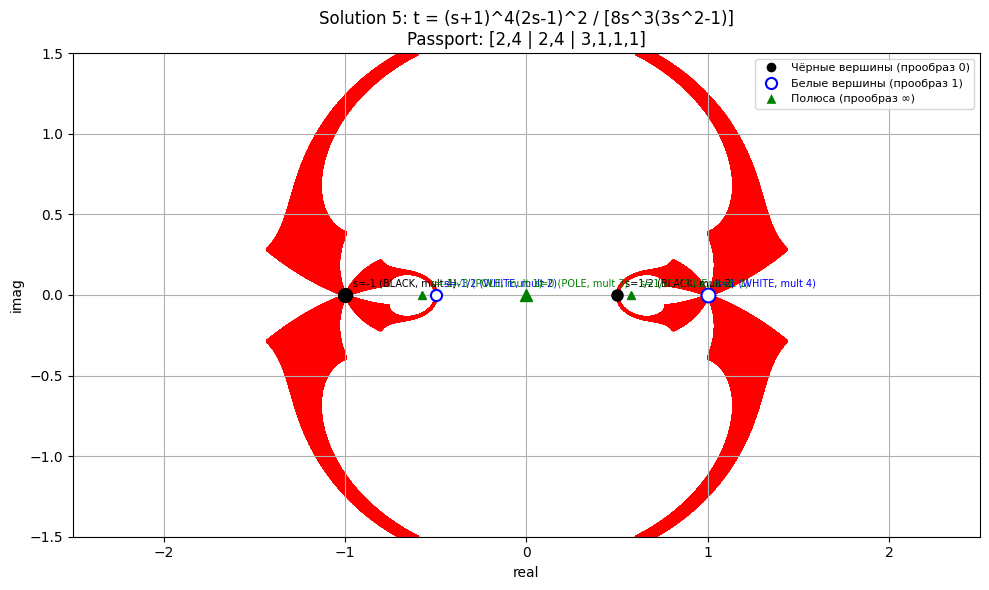

In [ ]:
#решение 5
import matplotlib.pyplot as plt
import numpy as np

# Окно охватывает все вещественные критические точки:
# s = -1, -1/2, 0, 1/sqrt(3)~0.577, 1/2, 1
# и полюса s=0, ±1/sqrt(3)
X_min = -2.5
X_max = 2.5
Y_min = -1.5
Y_max = 1.5
resolution = 4000
epsilon = 0.008

def beta(z):
    num = (z + 1)**4 * (2*z - 1)**2
    den = 8 * z**3 * (3*z**2 - 1)
    return num / den

a1 = np.array([])
b1 = np.array([])

inv_sqrt3 = 1.0 / np.sqrt(3)

for x in range(resolution):
    for y in range(resolution):
        z = complex(
            X_min + x*(X_max - X_min)/resolution,
            Y_min + y*(Y_max - Y_min)/resolution
        )
        try:
            # избегаем полюсов s=0 и s=±1/√3
            if (abs(z) > 0.04
                    and abs(z - inv_sqrt3) > 0.04
                    and abs(z + inv_sqrt3) > 0.04):
                B = beta(z)
                if -epsilon <= B.imag <= epsilon and 0 <= B.real <= 1:
                    a1 = np.append(a1, z.real)
                    b1 = np.append(b1, z.imag)
        except:
            pass

fig, axs = plt.subplots(figsize=(10, 6))
axs.axis((X_min, X_max, Y_min, Y_max))
axs.set_xlabel('real')
axs.set_ylabel('imag')
axs.set_title(
    "Solution 5: t = (s+1)^4(2s-1)^2 / [8s^3(3s^2-1)]\n"
    "Passport: [2,4 | 2,4 | 3,1,1,1]"
)
axs.grid(True)
axs.scatter(a1, b1, s=1, c="r")

# Все критические точки с подписями
critical_points = {
    's=-1 (BLACK, mult 4)': (-1, 0, 'black', 10),
    's=1/2 (BLACK, mult 2)': (0.5, 0, 'black', 8),
    's=-1/2 (WHITE, mult 2)': (-0.5, 0, 'white', 8),
    's=1 (WHITE, mult 4)': (1, 0, 'white', 10),
    's=0 (POLE, mult 3)': (0, 0, 'green', 8),
    's=1/√3 (POLE, mult 1)': (inv_sqrt3, 0, 'green', 6),
    's=-1/√3 (POLE, mult 1)': (-inv_sqrt3, 0, 'green', 6),
}

for label, (cx, cy, color, msize) in critical_points.items():
    if color == 'white':
        axs.plot(cx, cy, 'o', markersize=msize,
                 markerfacecolor='white', markeredgecolor='blue',
                 markeredgewidth=1.5)
    elif color == 'black':
        axs.plot(cx, cy, 'ko', markersize=msize)
    else:
        axs.plot(cx, cy, 'g^', markersize=msize)
    axs.annotate(label, (cx, cy),
                 textcoords="offset points",
                 xytext=(6, 6), fontsize=7,
                 color='blue' if color == 'white' else
                       'black' if color == 'black' else 'green')

# Легенда
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='black', markersize=8,
           label='Чёрные вершины (прообраз 0)'),
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='white', markeredgecolor='blue',
           markeredgewidth=1.5, markersize=8,
           label='Белые вершины (прообраз 1)'),
    Line2D([0],[0], marker='^', color='w',
           markerfacecolor='green', markersize=8,
           label='Полюса (прообраз ∞)'),
]
axs.legend(handles=legend_elements, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()


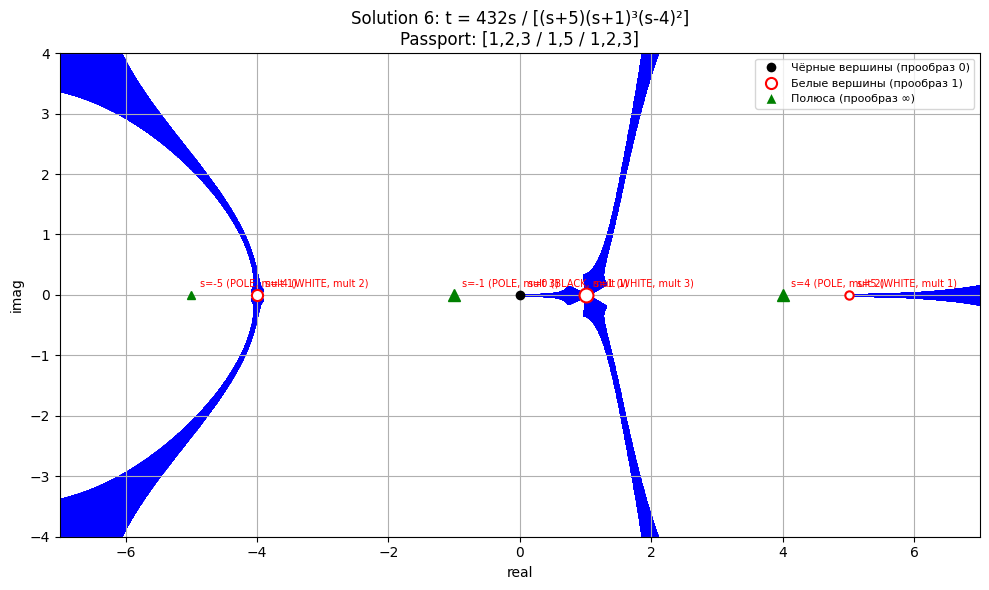

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Окно охватывает все вещественные критические точки:
# s = -5, -4, -1, 0, 1, 4, 5
X_min = -7.0
X_max = 7.0
Y_min = -4.0
Y_max = 4.0
resolution = 4000
epsilon = 0.008

def beta(z):
    # t = 432s / ((s+5)(s+1)³(s-4)²)
    num = 432 * z
    den = (z + 5) * (z + 1)**3 * (z - 4)**2
    return num / den

a1 = np.array([])
b1 = np.array([])

for x in range(resolution):
    for y in range(resolution):
        z = complex(
            X_min + x*(X_max - X_min)/resolution,
            Y_min + y*(Y_max - Y_min)/resolution
        )
        try:
            # избегаем полюсов s=-5, s=-1, s=4
            if (abs(z + 5) > 0.04
                    and abs(z + 1) > 0.04
                    and abs(z - 4) > 0.04):
                B = beta(z)
                if -epsilon <= B.imag <= epsilon and 0 <= B.real <= 1:
                    a1 = np.append(a1, z.real)
                    b1 = np.append(b1, z.imag)
        except:
            pass

fig, axs = plt.subplots(figsize=(10, 6))
axs.axis((X_min, X_max, Y_min, Y_max))
axs.set_xlabel('real')
axs.set_ylabel('imag')
axs.set_title(
    "Solution 6: t = 432s / [(s+5)(s+1)³(s-4)²]\n"
    "Passport: [1,2,3 / 1,5 / 1,2,3]"
)
axs.grid(True)
axs.scatter(a1, b1, s=1, c="blue")

# Все критические точки с подписями
# Белые вершины (t=1): s=1 (mult 3), s=-4 (mult 2), s=5 (mult 1)
# Черные вершины (t=0): s=0 (mult 1), s=∞ (mult 5)
# Полюса (t=∞): s=-5 (mult 1), s=-1 (mult 3), s=4 (mult 2)
critical_points = {
    's=1 (WHITE, mult 3)': (1, 0, 'white', 10),
    's=-4 (WHITE, mult 2)': (-4, 0, 'white', 8),
    's=5 (WHITE, mult 1)': (5, 0, 'white', 6),
    's=0 (BLACK, mult 1)': (0, 0, 'black', 6),
    's=-5 (POLE, mult 1)': (-5, 0, 'green', 6),
    's=-1 (POLE, mult 3)': (-1, 0, 'green', 8),
    's=4 (POLE, mult 2)': (4, 0, 'green', 8),
}

for label, (cx, cy, color, msize) in critical_points.items():
    if color == 'white':
        axs.plot(cx, cy, 'o', markersize=msize,
                 markerfacecolor='white', markeredgecolor='red',
                 markeredgewidth=1.5)
    elif color == 'black':
        axs.plot(cx, cy, 'ko', markersize=msize)
    else:
        axs.plot(cx, cy, 'g^', markersize=msize)
    axs.annotate(label, (cx, cy),
                 textcoords="offset points",
                 xytext=(6, 6), fontsize=7,
                 color='red')

# Легенда
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='black', markersize=8,
           label='Чёрные вершины (прообраз 0)'),
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='white', markeredgecolor='red',
           markeredgewidth=1.5, markersize=8,
           label='Белые вершины (прообраз 1)'),
    Line2D([0],[0], marker='^', color='w',
           markerfacecolor='green', markersize=8,
           label='Полюса (прообраз ∞)'),
]
axs.legend(handles=legend_elements, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

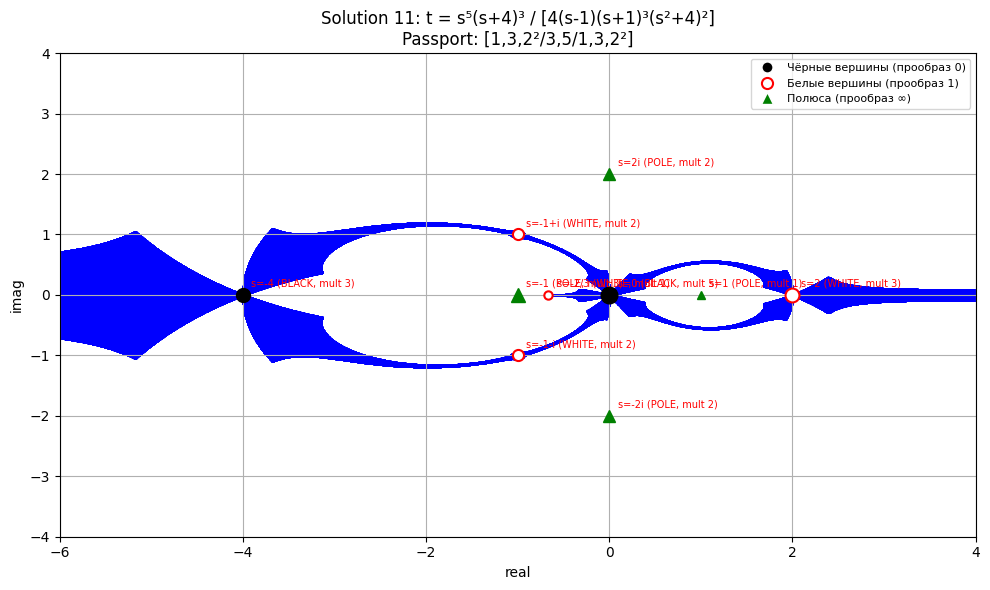

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Окно охватывает все критические точки:
# Вещественные: s = -4, -1, 0, 1, 2, -2/3
# Комплексные: s = ±2i, s = -1±i
X_min = -6.0
X_max = 4.0
Y_min = -4.0
Y_max = 4.0
resolution = 4000
epsilon = 0.008

def beta(z):
    # t = s^5(s+4)^3 / [4(s-1)(s+1)^3(s^2+4)^2]
    num = z**5 * (z + 4)**3
    den = 4 * (z - 1) * (z + 1)**3 * (z**2 + 4)**2
    return num / den

a1 = np.array([])
b1 = np.array([])

for x in range(resolution):
    for y in range(resolution):
        z = complex(
            X_min + x*(X_max - X_min)/resolution,
            Y_min + y*(Y_max - Y_min)/resolution
        )
        try:
            # избегаем полюсов s=1, s=-1, s=2i, s=-2i
            if (abs(z - 1) > 0.04
                    and abs(z + 1) > 0.04
                    and abs(z - 2j) > 0.04
                    and abs(z + 2j) > 0.04):
                B = beta(z)
                if -epsilon <= B.imag <= epsilon and 0 <= B.real <= 1:
                    a1 = np.append(a1, z.real)
                    b1 = np.append(b1, z.imag)
        except:
            pass

fig, axs = plt.subplots(figsize=(10, 6))
axs.axis((X_min, X_max, Y_min, Y_max))
axs.set_xlabel('real')
axs.set_ylabel('imag')
axs.set_title(
    "Solution 11: t = s⁵(s+4)³ / [4(s-1)(s+1)³(s²+4)²]\n"
    "Passport: [1,3,2²/3,5/1,3,2²]"
)
axs.grid(True)
axs.scatter(a1, b1, s=1, c="blue")

# Все критические точки с подписями
# Белые вершины (t=1): s=-2/3 (mult 1), s=2 (mult 3), s=-1+i (mult 2), s=-1-i (mult 2)
# Черные вершины (t=0): s=0 (mult 5), s=-4 (mult 3)
# Полюса (t=∞): s=1 (mult 1), s=-1 (mult 3), s=2i (mult 2), s=-2i (mult 2)
critical_points = {
    's=-2/3 (WHITE, mult 1)': (-2/3, 0, 'white', 6),
    's=2 (WHITE, mult 3)': (2, 0, 'white', 10),
    's=-1+i (WHITE, mult 2)': (-1, 1, 'white', 8),
    's=-1-i (WHITE, mult 2)': (-1, -1, 'white', 8),
    's=0 (BLACK, mult 5)': (0, 0, 'black', 12),
    's=-4 (BLACK, mult 3)': (-4, 0, 'black', 10),
    's=1 (POLE, mult 1)': (1, 0, 'green', 6),
    's=-1 (POLE, mult 3)': (-1, 0, 'green', 10),
    's=2i (POLE, mult 2)': (0, 2, 'green', 8),
    's=-2i (POLE, mult 2)': (0, -2, 'green', 8),
}

for label, (cx, cy, color, msize) in critical_points.items():
    if color == 'white':
        axs.plot(cx, cy, 'o', markersize=msize,
                 markerfacecolor='white', markeredgecolor='red',
                 markeredgewidth=1.5)
    elif color == 'black':
        axs.plot(cx, cy, 'ko', markersize=msize)
    else:
        axs.plot(cx, cy, 'g^', markersize=msize)
    axs.annotate(label, (cx, cy),
                 textcoords="offset points",
                 xytext=(6, 6), fontsize=7,
                 color='red')

# Легенда
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='black', markersize=8,
           label='Чёрные вершины (прообраз 0)'),
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='white', markeredgecolor='red',
           markeredgewidth=1.5, markersize=8,
           label='Белые вершины (прообраз 1)'),
    Line2D([0],[0], marker='^', color='w',
           markerfacecolor='green', markersize=8,
           label='Полюса (прообраз ∞)'),
]
axs.legend(handles=legend_elements, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()